In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 
from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

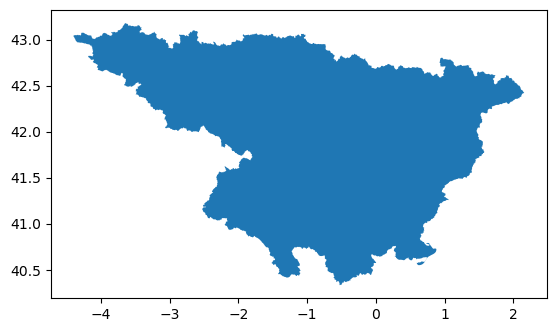

In [2]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [3]:
bbox = [-5, 40, 3, 44] # Ebro Basin
time_range = ("2020-01-01", "2021-12-31")

In [4]:
INPUT_DIR = "input_irrigation"

In [5]:
irr_store = new_data_store("file", root=INPUT_DIR)

In [6]:
irr_store.list_data_ids()

['clms.zarr', 'era5.zarr', 'landcover2020global.zarr']

In [7]:
clms_data = irr_store.open_data("clms.zarr")
lc = irr_store.open_data("landcover2020global.zarr")
cds_cube = irr_store.open_data("era5.zarr")

In [8]:
clms_data = clms_data.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))

### Soil Moisture (CLMS) - Interpolation

In [9]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [10]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 31)> Size: 248B
array([2458849.5, 2458850.5, 2458851.5, 2458852.5, 2458853.5, 2458854.5,
       2458855.5, 2458856.5, 2458857.5, 2458858.5, 2458859.5, 2458860.5,
       2458861.5, 2458862.5, 2458863.5, 2458864.5, 2458865.5, 2458866.5,
       2458867.5, 2458868.5, 2458869.5, 2458870.5, 2458871.5, 2458872.5,
       2458873.5, 2458874.5, 2458875.5, 2458876.5, 2458877.5, 2458878.5,
       2458879.5])
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

In [11]:
clms_data_chunked = clms_data.chunk({'time': -1})

sm_filled = clms_data_chunked['ssm'].interpolate_na(dim='time', method='linear') #, fill_value="extrapolate") ?

sm_clipped = sm_filled.clip(max=100)

sm_normalized = (sm_clipped - sm_clipped.min()) / (sm_clipped.max() - sm_clipped.min())

sm_normalized

<xarray.DataArray 'ssm' (time: 31, lat: 448, lon: 896)> Size: 100MB
dask.array<truediv, shape=(31, 448, 896), dtype=float64, chunksize=(31, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

In [12]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,       
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized", 
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [13]:
SWI = SWI.transpose("time", "lat", "lon")

SWI = chunk_dataset(SWI, chunk_sizes={"time":-1})
SWI

<xarray.DataArray (time: 31, lat: 448, lon: 896)> Size: 100MB
dask.array<transpose, shape=(31, 448, 896), dtype=float64, chunksize=(31, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

In [14]:
%%time
irr_store.write_data(SWI.to_dataset(name="SWI"), "soil_moisture_filled.zarr")

CPU times: user 17.9 s, sys: 404 ms, total: 18.3 s
Wall time: 18 s


'soil_moisture_filled.zarr'

In [15]:
soil_moisture = irr_store.open_data("soil_moisture_filled.zarr")

## LandCover - Subset and Binarization

In [16]:
lc_subset = lc.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))
lc_subset

<xarray.Dataset> Size: 50MB
Dimensions:              (lat: 1440, lon: 2880, bounds: 2)
Coordinates:
  * lat                  (lat) float64 12kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float64 23kB -4.999 -4.996 -4.993 ... 2.996 2.999
    time                 datetime64[ns] 8B ...
Dimensions without coordinates: bounds
Data variables:
    change_count         (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 23kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    lccs_class           (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 46kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
    observation_count    (lat, lon) uint16 8MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    processed_flag       (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [17]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_subset.lccs_class.where(lc_subset["lccs_class"].isin(keep_classes))

keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)

lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")

lc_binary

<xarray.DataArray 'lccs_class' (lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1440, 2880), dtype=uint8, chunksize=(1440, 1800), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 12kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 23kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
    time     datetime64[ns] 8B 2020-01-01

## CDS - Hourly to Daily conversion and units modification

In [18]:
stl1_daily = cds_cube["stl1"].resample(time="1D").mean()
pev_daily  = cds_cube["pev"].resample(time="1D").sum()
tp_daily   = cds_cube["tp"].resample(time="1D").max()
sf_daily   = cds_cube["sf"].resample(time="1D").mean()

cds_cube_daily = xr.merge([stl1_daily, pev_daily, tp_daily, sf_daily])

In [19]:
def convert_m_to_mm(dataarray, update_long_name=True):
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted

In [22]:
cds_cube_daily["pev"] =  convert_m_to_mm(cds_cube_daily["pev"] * -1) # Making it positive values only
cds_cube_daily["tp"] =  convert_m_to_mm(cds_cube_daily["tp"])
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 40, lon: 80, time: 31)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Soil temperature level 1
    standard_name:                            surface_temperature
    units:                                    K

## Resample ERA5 (CDS) and LC to Soil Moisture (CLMS) grid

In [23]:
gm_sm = GridMapping.from_dataset(soil_moisture)

gm_cds = GridMapping.from_dataset(cds_cube_daily)

gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))

print(gm_sm, gm_cds, gm_lc)

<xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7a93bc70fef0> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7a93d71e9e80> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7a93df3d5220>


In [24]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
    spatial_ref  int64 8B 0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Soil temperature level 1
    standard_name:                            surface_temperature
    units:                                    K

In [25]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary"), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
    spatial_ref  int64 8B 0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [26]:
print(GridMapping.from_dataset(cds_in_gm_sm), GridMapping.from_dataset(lc_in_gm_sm))

<xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7a93df563f20> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7a93d71391f0>


## Masking the data to Ebro Basin and only landcover classes for croplands

In [27]:
cds_masked_full = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked = mask_dataset_by_geometry(cds_masked_full, gdf.geometry[0])

soil_moisture_masked_full = soil_moisture.where(lc_in_gm_sm.lc_binary == 1)
soil_moisture_masked = mask_dataset_by_geometry(soil_moisture_masked_full, gdf.geometry[0])

## Align and merge all these dataset variables into one cube

In [28]:
soil_moisture_aligned, cds_aligned = xr.align(
    soil_moisture_masked,
    cds_masked,
    join="outer" # because SSM does not have data for 2 days
)

In [29]:
soil_moisture_aligned = chunk_dataset(soil_moisture_aligned, chunk_sizes={"time":-1})
cds_aligned = chunk_dataset(cds_aligned, chunk_sizes={"time":-1})

In [31]:
ds_combined = xr.merge([soil_moisture_aligned, cds_aligned, lc_in_gm_sm]) 
ds_combined

/tmp/ipykernel_973342/2526478985.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.merge([soil_moisture_aligned, cds_aligned, lc_in_gm_sm])
/tmp/ipykernel_973342/2526478985.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.merge([soil_moisture_aligned, cds_aligned, lc_in_gm_sm])
/tmp/ipykernel_973342/2526478985.py:1: FutureW

<xarray.Dataset> Size: 299MB
Dimensions:      (lat: 448, lon: 896, time: 31)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 100MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-09-02T15:08:25.853234

In [32]:
chunked_ds = chunk_dataset(ds_combined, chunk_sizes={"time":-1, "lat":128, "lon":128}, format_name="zarr")
chunked_ds

<xarray.Dataset> Size: 299MB
Dimensions:      (lat: 448, lon: 896, time: 31)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-09-02T15:08:25.853234

In [33]:
%%time

irr_store.write_data(chunked_ds, "irrigation_input.zarr")

CPU times: user 12.8 s, sys: 763 ms, total: 13.5 s
Wall time: 2.25 s


'irrigation_input.zarr'

In [34]:
irrigation_input=irr_store.open_data("irrigation_input.zarr")
irrigation_input

<xarray.Dataset> Size: 299MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    SWI          (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-02T15:08:25.853234
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_resolution:  0.008928575
    geospatial_lon_units:       degrees_east

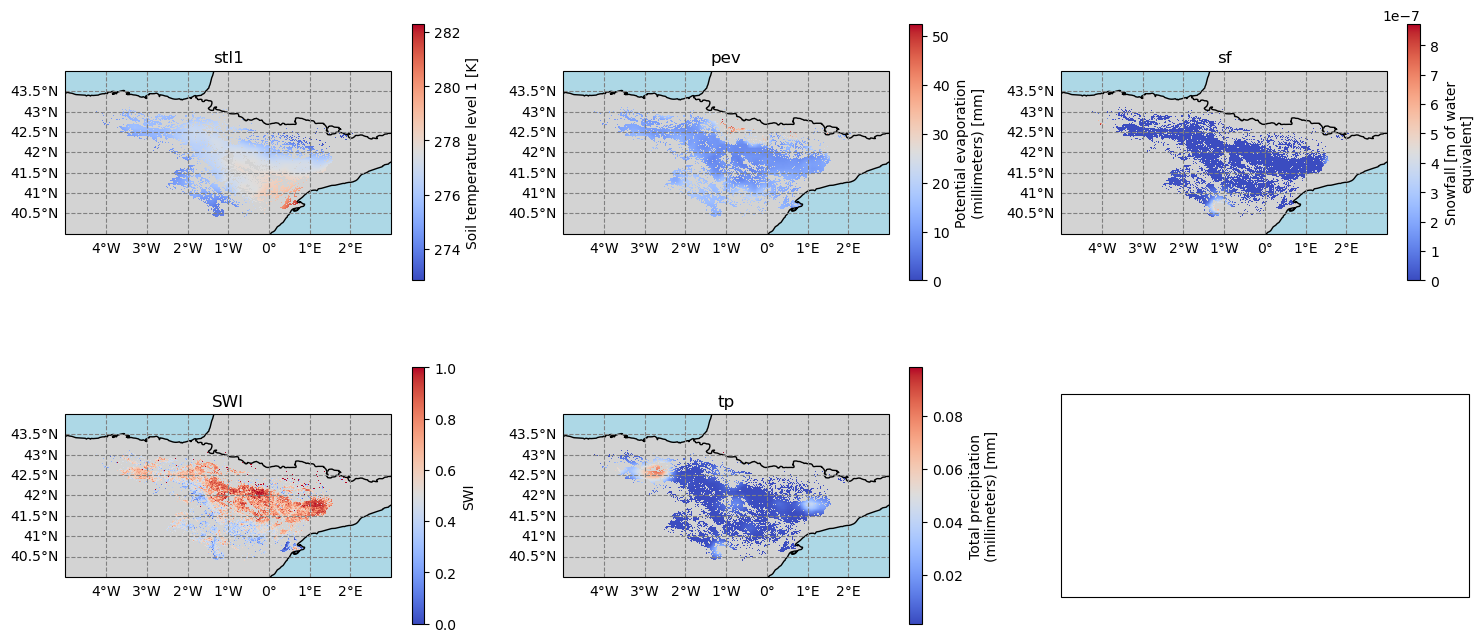

CPU times: user 5.02 s, sys: 179 ms, total: 5.2 s
Wall time: 5.22 s


In [35]:
%%time

ds = irrigation_input.isel(time=5)
vars_to_plot = ["stl1", "pev", "sf", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False


plt.tight_layout()
plt.show()